![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# 03 | Hypotheses and Visualisation

*Project 1 — SQL: From Data to Insight*

**Team:**
**Dataset:**

---

**This notebook is your report.** It is read on its own, by someone who has not seen notebooks 01 and 02, so it needs the prose as much as the code: the question, the evidence, and what you concluded. Keep the messy exploration in the other two.

> **Done when:** someone who has never met your project can read this top to bottom and understand what you asked, what the data said, and how confident they should be.

The sections below are a suggested route, not a form to fill in. Add sections, drop them, reorder them — what is graded is the analysis, not whether you kept the scaffold.

---
## 0. Setup

In [1]:
import sys
sys.path.append("..")          # so `src` is importable from inside notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from pathlib import Path
from src.functions import *

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

---
## 1. The question

What you set out to find out, and why it matters. Your research questions from notebook 01, with the hypothesis for each.

**1. Which European countries recovered their pre-pandemic GDP levels by 2024?**
- The pandemic affected European economies differently. Comparing recovery trajectories helps identify which countries returned to their previous levels of economic output and whether that recovery was sustained.
- Hypothesis (H1): Most EU countries recovered their pre-pandemic GDP levels by 2024, but the timing and extent of recovery differed substantially across countries.
- Method: Reconstruct a real GDP index for each country, setting 2019 equal to 100, and compare economic performance through 2024.

**2. Was higher inflation in 2022 associated with weaker GDP growth in 2023?**
- The 2022 inflation shock coincided with significant economic uncertainty. Investigating subsequent GDP growth helps establish whether countries experiencing higher inflation also experienced weaker economic performance.
- Hypothesis (H1): Countries with higher inflation in 2022 experienced lower real GDP growth in 2023.
- Null hypothesis (H0): There is no correlation between inflation in 2022 and GDP growth in 2023 across EU countries.
- Method: Scatter plot and Pearson and Spearman correlation analyses.

**3. Was the reduction in inflation between 2022 and 2024 associated with rising unemployment?**
- Lowering inflation can coincide with weaker economic activity and changes in employment. This question examines whether European countries experienced higher unemployment as inflation declined.
- Hypothesis (H1): Countries experiencing larger reductions in inflation between 2022 and 2024 also experienced larger increases in unemployment.
- Null hypothesis (H0): There is no correlation between changes in inflation and changes in unemployment.
- Method: Calculate changes in both indicators in percentage points, create a scatter plot and conduct correlation analyses.

**4. Did European economies become more similar or more divergent between 2019 and 2024?**
- Economic shocks can affect countries unevenly. Examining cross-country differences reveals whether European economies experienced increasingly different economic outcomes or returned towards more similar conditions.
- Hypothesis (H1): Cross-country dispersion in GDP growth and inflation increased during the respective economic shocks but declined again by 2024. Unemployment dispersion may have followed a different trajectory.
- Method: Calculate the annual cross-country standard deviation and range of each economic indicator from 2019 to 2024, and visualise their evolution.

---
## 2. The data

Where it came from, what one row is, and what your database looks like. Show the ERD.

1. The dataset comes from the World Bank's World Development Indicators (https://databank.worldbank.org/source/world-development-indicators)

I decided to analyze the 27 EU member states between 2019 and 2024, using three economic indicators:
**Indicator World Bank                    code	            Unit**
Real GDP growth	                        NY.GDP.MKTP.KD.ZG	Annual % change
Consumer price inflation	            FP.CPI.TOTL.ZG	    Annual % change
Unemployment, modelled ILO estimate	    SL.UEM.TOTL.ZS	    % of labour force

I narrowed the dataset that consists of three CSV files:the economic observations, country metadata and indicator metadata.
The data was cleaned using pandas, restricted to the countries, indicators and years relevant to the research, and converted from wide to long format before being imported into SQLite. 

2. The cleaned dataset is organised into three relational tables:
    
    **Table**          //   **What one row represents**                                                    //       **Primary keys**
    
    countries         //   One EU country, including its name, country code and region	                  //         country_code
    
    indicators        //   One economic indicator, including its name, description and measurement unit	  //         indicator_code
    
    observations      //	One country's value for one indicator in one year	                              //   country_code, indicator_code, year

The observations table is the main analytical table. Each observation references exactly one country and one indicator through foreign keys. In total, I analyzed 27 cpuntries over the span of 6 years (2019 - 20024) and evaluated 3 indicators. In total there were 486 country related observations. 

Also, the database uses two one-to-many relationships: one country can have many observations, and one indicator can have many observations. The composite primary key in observations prevents duplicate records for the same country, indicator and year. Below is the ERD to ilustrate that relationship.





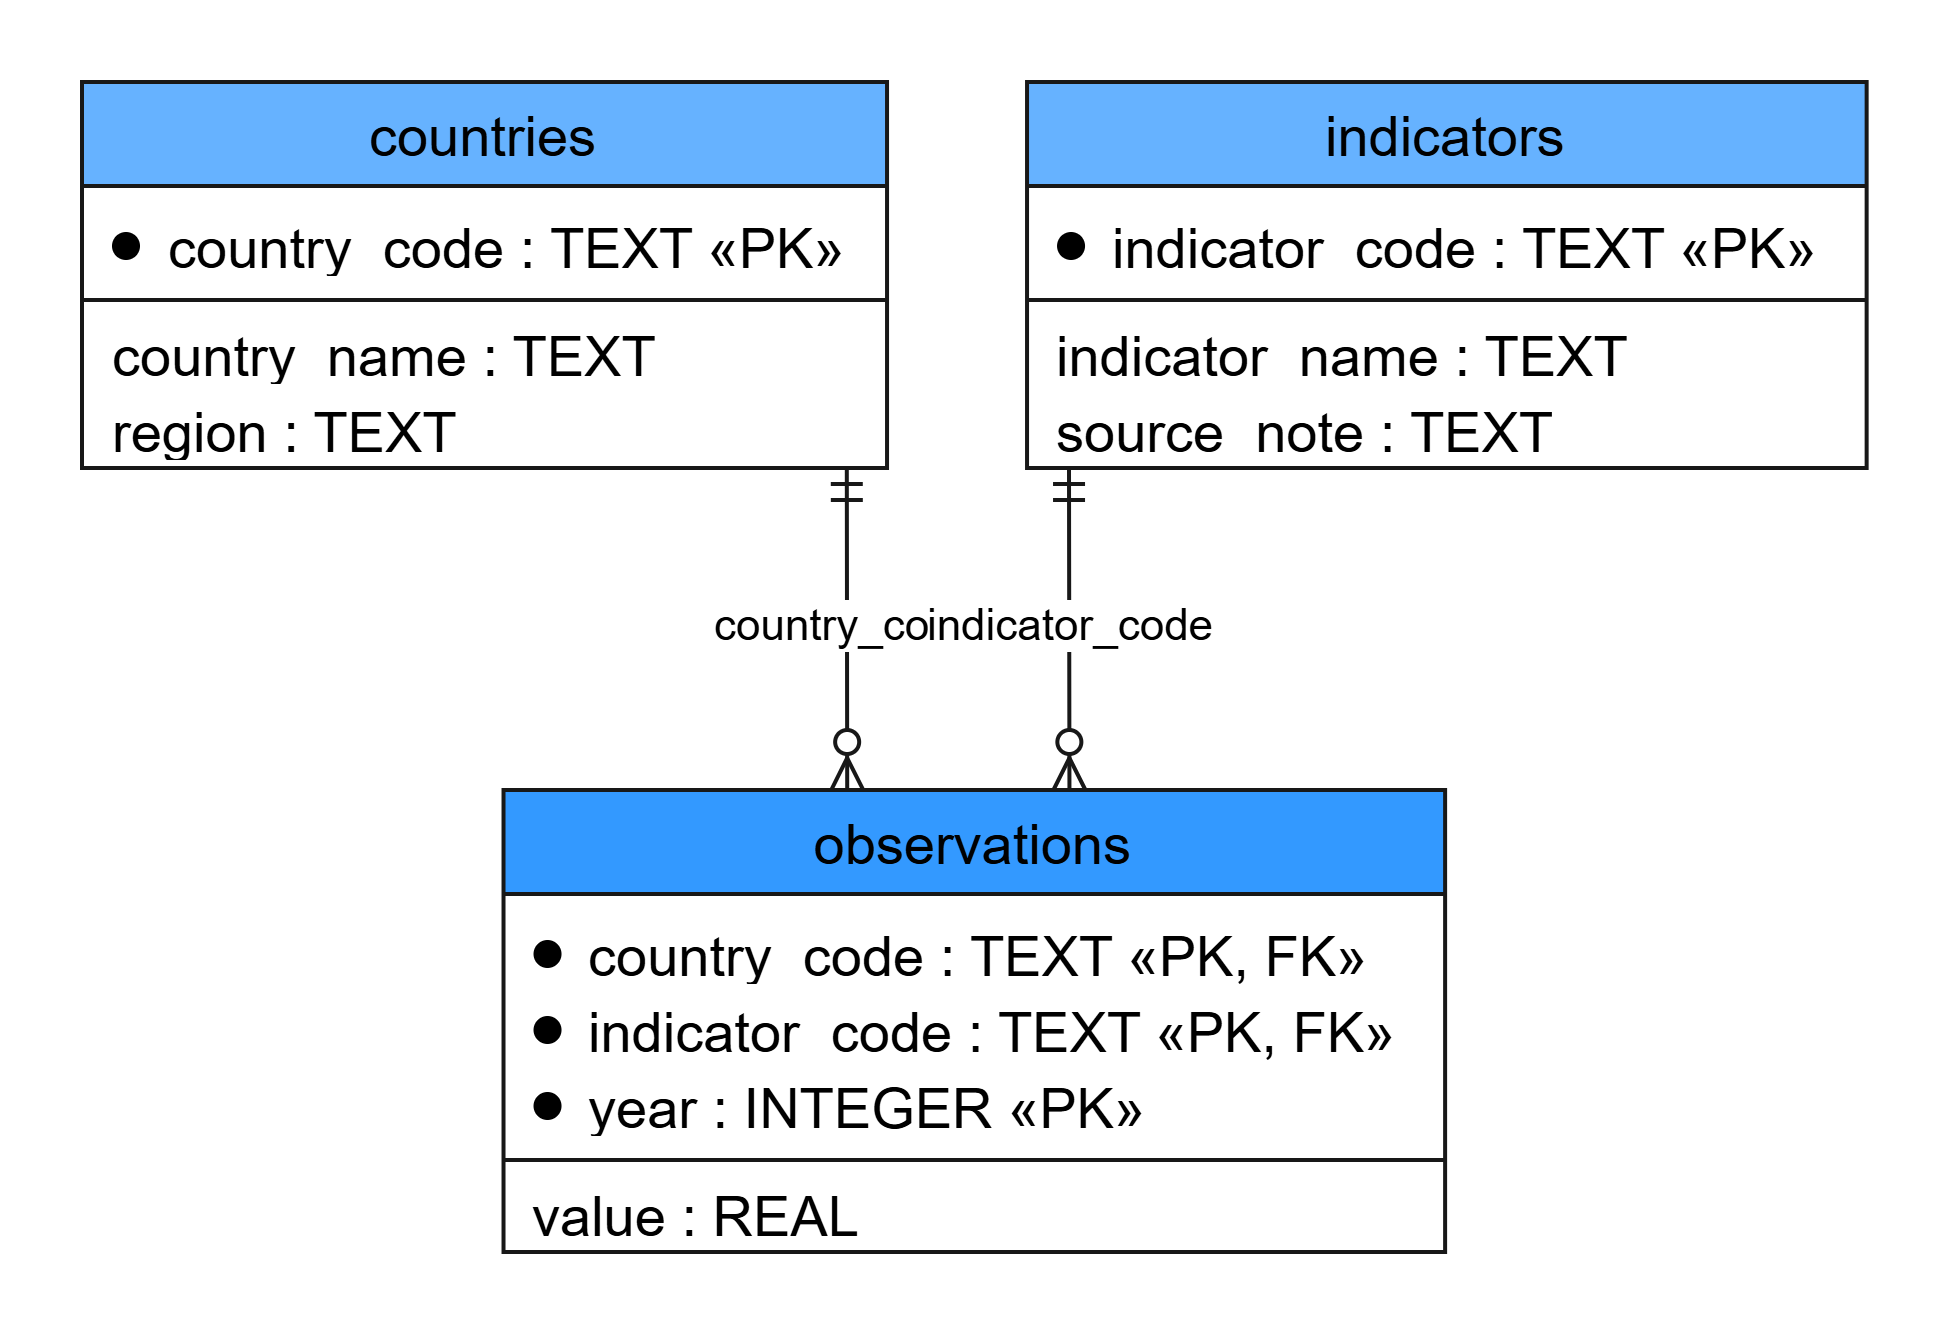

In [2]:
# Project root
project_root = Path.cwd()

# If notebook is inside the notebooks folder
if project_root.name == "notebooks":
    project_root = project_root.parent

# Path to SQLite database
db_path = project_root / "data" / "project.db"

print("Database path:", db_path)
print("Database exists:", db_path.exists())

# Connect to database
conn = sqlite3.connect(db_path)

print("Database connected successfully.")

Database path: c:\Users\jjwei\Ironhack-Projects\project-1-eda-sql\data\project.db
Database exists: True
Database connected successfully.


In [3]:
## Verifying what was descrtibed previously about the table
pd.read_sql("""
    SELECT 'countries' AS table_name, COUNT(*) AS rows
    FROM countries

    UNION ALL

    SELECT 'indicators', COUNT(*)
    FROM indicators

    UNION ALL

    SELECT 'observations', COUNT(*)
    FROM observations;
""", conn)

,table_name,rows
0,countries,27
1,indicators,3
2,observations,486


In [4]:
##Sample to show how the table observations table looks like 
pd.read_sql("""
    SELECT
        c.country_name,
        i.indicator_name,
        o.year,
        o.value
    FROM observations AS o
    JOIN countries AS c
        ON o.country_code = c.country_code
    JOIN indicators AS i
        ON o.indicator_code = i.indicator_code
    LIMIT 5;
""", conn)

,country_name,indicator_name,year,value
0,Austria,"Inflation, consumer prices (annual %)",2019,1.530896
1,Austria,GDP growth (annual %),2019,1.754976
2,Austria,"Unemployment, total (% of total labor force) (...",2019,4.560000
3,Belgium,"Inflation, consumer prices (annual %)",2019,1.436820
4,Belgium,GDP growth (annual %),2019,2.442890


---
## 3. Analysis

One section per question: the query, the result, and a sentence saying what it means. Five queries minimum across the notebook, and the aggregation belongs in SQL rather than in pandas afterwards. Keep the queries in `sql/queries.sql` — this notebook runs them.

In [5]:
db_path = Path("../data/project.db").resolve()
#making sure the database is connected correctly
assert db_path.is_file(), f"Database not found: {db_path}"

conn = sqlite3.connect(db_path)

print("Connected to:", db_path)

Connected to: C:\Users\jjwei\Ironhack-Projects\project-1-eda-sql\data\project.db


In [6]:

sql_path = Path("../sql/queries.sql").resolve()

print(sql_path)
print(sql_path.exists())

C:\Users\jjwei\Ironhack-Projects\project-1-eda-sql\sql\queries.sql
True


In [7]:
## ensuring that the queries are readable
import re

sql_text = sql_path.read_text(encoding="utf-8")

headings = re.findall(
    r"(?im)^\s*--\s*QUERY\s+([1-6])\b",
    sql_text
)

print("Queries found:", headings)

Queries found: ['1', '2', '3', '4', '5', '6']


In [8]:
#loading queries
from IPython.display import display, Markdown

# Read your SQL file
sql_text = sql_path.read_text(encoding="utf-8")

# Separate the setup SQL from the six queries
parts = re.split(
    r"(?im)^[ \t]*--[ \t]*QUERY[ \t]+([1-6])\b[^\n]*(?:\n|$)",
    sql_text
)

setup_sql = parts[0]

queries = {
    int(parts[i]): parts[i + 1].strip()
    for i in range(1, len(parts), 2)
}

print("Queries loaded:", sorted(queries.keys()))

Queries loaded: [1, 2, 3, 4, 5, 6]


In [9]:
#connecting to the GDP-index view created in SQLite
assert db_path.is_file(), "Database not found."

conn = sqlite3.connect(db_path)

# Check that the GDP-index view exists
view_exists = conn.execute("""
    SELECT 1
    FROM sqlite_master
    WHERE type = 'view'
      AND name = 'gdp_index_2019'
""").fetchone()

if not view_exists:
    conn.executescript(setup_sql)

print("Database ready.")

Database ready.


In [10]:
#function to display the SQL queries and its results.
def run_query(number):
    sql = queries[number]

    display(Markdown(f"### Query {number}"))
    display(Markdown(f"```sql\n{sql}\n```"))

    result = pd.read_sql_query(sql, conn)

    print(f"Rows returned: {len(result)}")
    display(result.head(30))

    return result

**Research Question 1 — GDP recovery**

In [11]:
gdp_trajectories = run_query(1)
gdp_recovery = run_query(2)

### Query 1

```sql
Select 
	country_name,
	year,
	ROUND(gdp_index, 2) AS gdp_index
FROM gdp_index_2019
ORDER BY country_name, year = 2024;


/* QUERY 2: Recovery status and first recovery year.
 - Methodology: Classified countries by whether their 2024 GDP index reached their 2019 GDP level. As most countries (not all) experienced a decline in 2020,
                it finds the first year from 2021 through 2024 in which they reached the baseline. (A country may reach 100 and subsequently fall below it again.)
 - Findings: a)  2 countries (Ireland and Lithuania) did not experience economic contraction in 2020
			b)  Of the 25 countries that experienced a GDP contraction in 2020, 17 had already returned to their pre-pandemic GDP levels in 2021. The remaining eight first recovered in 2022.
			c)  It sems that The depth of the pandemic contraction did not determine recovery speed. Croatia contracted 8.31% in 2020, but recovered the next year
				While Finland experienced a smaller contraction of 2.49% and initially recovered in 2021, but subsequently fell below its 2019 level.
				Germany recovered in 2022, but but ended 2024 at just 100.04
-- Limitation: GDP indices measure changes in aggregate real output relative to 2019, not GDP per capita or changes in living standards.
*/
```

Rows returned: 162


,country_name,year,gdp_index
0,Austria,2019,100.00
1,Austria,2020,93.68
2,Austria,2021,98.29
3,Austria,2022,103.53
4,Austria,2023,102.72
5,Austria,2024,102.04
6,Belgium,2019,100.00
7,Belgium,2020,95.21
8,Belgium,2021,101.16
9,Belgium,2022,105.23


### Query 2

```sql
WITH recovery AS (
    SELECT
        country_name,
        MAX(CASE WHEN year = 2020
            THEN gdp_index END) AS gdp_2020,
        MAX(CASE WHEN year = 2024
            THEN gdp_index END) AS gdp_2024,
        MIN(CASE
            WHEN year BETWEEN 2021 AND 2024
                 AND gdp_index >= 100
            THEN year
        END) AS first_year_at_baseline
    FROM gdp_index_2019
    GROUP BY country_name
)
SELECT
    country_name,
    ROUND(gdp_2020, 2) AS gdp_2020,
    ROUND(gdp_2024, 2) AS gdp_2024,
    CASE
        WHEN gdp_2024 IS NULL THEN 'Incomplete data'
        WHEN gdp_2020 >= 100
            THEN 'No contraction in 2020'
        WHEN gdp_2024 >= 100
            THEN 'Recovered by 2024'
        ELSE 'Below 2019 level in 2024'
    END AS recovery_status,
    CASE
        WHEN gdp_2020 < 100
        THEN first_year_at_baseline
    END AS first_recovery_year
FROM recovery
ORDER BY gdp_2024 DESC;

/* QUERY 3 -- Research question 2: Inflation in 2022 and GDP growth in 2023
 - Methodology: compare 2022 inflation with growth in 2023
 - Findings: a) There seems to be an apparent negative relationship between inflation in 2022 and GDP growth in 2023.
			Needs a bivariate comparison (Pearson and/or Spearman correlation) to identify if there is statistical correlation.
			b) Countries with similar inflation rates experienced substantially different economic outcomes: Estonia recorded 19.40% inflation and -2.74% GDP
			growth, while Lithuania recorded 19.71% inflation and positive GDP growth of 0.74%.
- Limitation: This is a cross-country correlation analysis. It does not establish that inflation caused subsequent changes in economic growth.
*/
```

Rows returned: 27


,country_name,gdp_2020,gdp_2024,recovery_status,first_recovery_year
0,Ireland,107.15,133.93,No contraction in 2020,NaN
1,Malta,96.54,131.92,Recovered by 2024,2021.0
2,Cyprus,96.78,126.26,Recovered by 2024,2021.0
3,Croatia,91.69,119.37,Recovered by 2024,2021.0
4,Bulgaria,96.87,114.29,Recovered by 2024,2021.0
5,Poland,97.96,113.88,Recovered by 2024,2021.0
6,Lithuania,100.04,113.20,No contraction in 2020,NaN
7,Slovenia,95.91,111.19,Recovered by 2024,2021.0
8,Romania,96.40,109.44,Recovered by 2024,2021.0
9,Denmark,98.22,109.38,Recovered by 2024,2021.0


**Research Question 2 — Inflation and GDP growth**

In [12]:
inflation_growth = run_query(3)


### Query 3

```sql
SELECT
    c.country_name,
    inf.value AS inflation_2022,
    gdp.value AS gdp_growth_2023
FROM observations AS inf
JOIN observations AS gdp
    ON inf.country_code = gdp.country_code
JOIN countries AS c
    ON inf.country_code = c.country_code
WHERE inf.indicator_code = 'FP.CPI.TOTL.ZG'
    AND inf.year = 2022
    AND gdp.indicator_code = 'NY.GDP.MKTP.KD.ZG'
    AND gdp.year = 2023
    AND inf.value IS NOT NULL
    AND gdp.value IS NOT NULL
ORDER BY inflation_2022 DESC;


/*QUERY 4 -- Research question 2: Comparing subsequent growth in high and low inflation countries (supplement comparison)
	- Methodology: Split the exact sample used in Query 3 by the unweighted mean 2022 inflation, then computes group averages.
	- Findings: a) The ten countries with above-average inflation in 2022 recorded average GDP growth of 0.63% in 2023. The other 17 countries recorded 1.33%.
				difference of GDP 0.70% points, while the inflation difference was 7.38% on average
				b) Countries with lower inflation initially appear to have experienced stronger subsequent growth.
	- Limitations: a) look for outliers countries to see if any affect the unwheighted mean of the sample
					b) according to Query 3, there seems to be no causation between inflation and economic growth.
	*/
```

Rows returned: 27


,country_name,inflation_2022,gdp_growth_2023
0,Lithuania,19.705046,0.739537
1,Estonia,19.398263,-2.744219
2,Latvia,17.310283,-0.941606
3,Bulgaria,15.325259,1.681511
4,Czechia,15.100165,0.047580
5,Hungary,14.608144,-0.817107
6,Poland,14.429451,0.249611
7,Romania,13.795489,2.257734
8,Slovak Republic,12.774146,2.112636
9,Croatia,10.780581,3.762041


Calculating Pearson and Spearman correlation for inflation 2022 and GDP growth 2023

In [13]:
inflation_groups = run_query(4)

### Query 4

```sql
WITH paired AS (
    SELECT
        inf.country_code,
        inf.value AS inflation_2022,
        gdp.value AS gdp_growth_2023
    FROM observations AS inf
    JOIN observations AS gdp
        ON inf.country_code = gdp.country_code
    WHERE inf.indicator_code = 'FP.CPI.TOTL.ZG'
        AND inf.year = 2022
        AND gdp.indicator_code = 'NY.GDP.MKTP.KD.ZG'
        AND gdp.year = 2023
        AND inf.value IS NOT NULL
        AND gdp.value IS NOT NULL
),
classified AS (
    SELECT
        *,
        CASE
            WHEN inflation_2022 > (
                SELECT AVG(inflation_2022)
                FROM paired
            )
            THEN 'Above-average inflation'
            ELSE 'At or below-average inflation'
        END AS inflation_group
    FROM paired
)
SELECT
    inflation_group,
    COUNT(*) AS country_count,
    ROUND(AVG(inflation_2022), 2) AS avg_inflation,
    ROUND(AVG(gdp_growth_2023), 2) AS avg_gdp_growth
FROM classified
GROUP BY inflation_group
HAVING COUNT(*) >= 2;

/*QUERY 5 -- Research Question 3: Disinflation and unemployment: Was the reduction in inflation between 2022 and 2024 associated with rising unemployment?
	- Methodology: Calculated the change in inflation and the change in unemployment for the same country between 2022 and 2024. Both in percentage points. 
	Includes all countries in pairs.
	- Findings: a) Inflation declined in all 27 countries. However, unemployment increased in 16 countries and decreased in 10 countries. Poland only did not experience change in unemployment
				b) Lithuania experienced the largest reduction in inflation (-18.99%), accompanied by a 0.90% increase in unemployment.
				c) Estonia recorded the largest increase in unemployment (+2.03%), while Greece recorded the largest decrease (-2.41%).
	- Limitations: a) Need to perform bivariate analysis (Pearson and Spearman) to see if there is siginificant statistical analysis
					b)Cross-country correlations do not establish causation or isolate the effects of monetary policy and other economic developments.
*/
```

Rows returned: 2


,inflation_group,country_count,avg_inflation,avg_gdp_growth
0,Above-average inflation,10,15.32,0.63
1,At or below-average inflation,17,7.94,1.33


**Research Question 3 — Inflation and unemployment**

In [14]:
inflation_unemployment = run_query(5)

### Query 5

```sql
SELECT
    c.country_name,
    ROUND(i24.value - i22.value, 2)
        AS inflation_change_pp,
    ROUND(u24.value - u22.value, 2)
        AS unemployment_change_pp
FROM countries AS c
JOIN observations AS i22
    ON c.country_code = i22.country_code
JOIN observations AS i24
    ON c.country_code = i24.country_code
JOIN observations AS u22
    ON c.country_code = u22.country_code
JOIN observations AS u24
    ON c.country_code = u24.country_code
WHERE i22.indicator_code = 'FP.CPI.TOTL.ZG'
    AND i22.year = 2022
    AND i24.indicator_code = 'FP.CPI.TOTL.ZG'
    AND i24.year = 2024
    AND u22.indicator_code = 'SL.UEM.TOTL.ZS'
    AND u22.year = 2022
    AND u24.indicator_code = 'SL.UEM.TOTL.ZS'
    AND u24.year = 2024
    AND i22.value IS NOT NULL
    AND i24.value IS NOT NULL
    AND u22.value IS NOT NULL
    AND u24.value IS NOT NULL
ORDER BY inflation_change_pp;

/* Query 6 -- Research question 4: Did European economies become more similar or more divergent between 2019 and 2024?
	Methodology: For each indicator and year, I calculated the country count, unweighted country mean, range, and sample variance. 
				For each INDICATOR, I used only countries with a non-NULL observations, so the composition of that indicator's sample is constant across the chart.
				Different indicators may have different complete-country samples.
	Further analysis : In pandas, need to take sqrt(sample_variance) to get standard deviation. Then plot each indicator separately. This tests dispersion of economic rates,
						not convergence of GDP levels or living standards.
	Findings: a) GDP growth dispersion increased sharply during the COVID-19 shock. Sample variance rose from 1.99 in 2019 to 12.63 in 2020, while the range increased from 5.45 to 18.09%.
			  b) GDP-growth dispersion subsequently declined, reaching a variance of 2.61 in 2024. This was close to, although still above, the 2019 level.
			  c) Inflation showed an even stronger temporary divergence. Variance increased from 1.00 in 2019 to 16.93 in 2022, during the inflation shock. 
			  By 2024 it had fallen to 1.07, almost returning to its pre-shock level.
			  d)Unemployment followed a different pattern: Its variance declined steadily from 10.67 in 2019 to 4.70 in 2024, a reduction of about 56%.
			  The unemployment range also fell from 15.03 to 8.80 percentage points.
			  -- Limitation: Dispersion in annual GDP growth, inflation and unemployment does not measure convergence in GDP levels, income or living standards.
*/
```

Rows returned: 27


,country_name,inflation_change_pp,unemployment_change_pp
0,Lithuania,-18.99,0.90
1,Latvia,-16.04,0.08
2,Estonia,-15.88,2.03
3,Bulgaria,-12.88,0.05
4,Czechia,-12.66,0.38
5,Hungary,-10.90,0.92
6,Poland,-10.64,-0.00
7,Slovak Republic,-10.02,-0.84
8,Romania,-8.07,-0.21
9,Croatia,-7.81,-1.81


**Research Question 4 — Economic divergence**

In [15]:
dispersion = run_query(6)

### Query 6

```sql
WITH complete_countries AS (
    SELECT
        country_code,
        indicator_code
    FROM observations
    WHERE year BETWEEN 2019 AND 2024
        AND value IS NOT NULL
    GROUP BY country_code, indicator_code
    HAVING COUNT(DISTINCT year) = 6
),
annual_stats AS (
    SELECT
        o.indicator_code,
        o.year,
        COUNT(*) AS country_count,
        AVG(o.value) AS mean_value,
        MIN(o.value) AS min_value,
        MAX(o.value) AS max_value,
        SUM(o.value) AS total,
        SUM(o.value * o.value) AS sum_squares
    FROM observations AS o
    JOIN complete_countries AS cc
        ON o.country_code = cc.country_code
        AND o.indicator_code = cc.indicator_code
    WHERE o.year BETWEEN 2019 AND 2024
    GROUP BY o.indicator_code, o.year
    HAVING COUNT(*) >= 2
)
SELECT
    i.indicator_name,
    a.year,
    a.country_count,
    ROUND(a.mean_value, 2) AS mean_value,
    ROUND(a.max_value - a.min_value, 2) AS range_pp,
    ROUND(        (a.sum_squares - a.total * a.total / a.country_count) / (a.country_count - 1), 4) 
		AS sample_variance
FROM annual_stats AS a
JOIN indicators AS i
    ON a.indicator_code = i.indicator_code
ORDER BY i.indicator_name, a.year;
```

Rows returned: 18


,indicator_name,year,country_count,mean_value,range_pp,sample_variance
0,GDP growth (annual %),2019,27,2.93,5.45,1.9885
1,GDP growth (annual %),2020,27,-4.06,18.09,12.6278
2,GDP growth (annual %),2021,27,7.42,13.58,9.0532
3,GDP growth (annual %),2022,27,3.59,9.96,6.8170
4,GDP growth (annual %),2023,27,1.07,13.38,6.6431
5,GDP growth (annual %),2024,27,1.79,6.87,2.6099
6,"Inflation, consumer prices (annual %)",2019,27,1.70,3.58,1.0040
7,"Inflation, consumer prices (annual %)",2020,27,0.78,4.62,1.5051
8,"Inflation, consumer prices (annual %)",2021,27,2.88,3.89,1.3829
9,"Inflation, consumer prices (annual %)",2022,27,10.68,14.48,16.9290


---
## 4. Visualisation

At least two charts that carry an argument. Labelled axes, a title that states the finding, and a chart type that suits the data.

**Graph for Research question 1: GDP Recovery** (Indexed GDP line chart) 

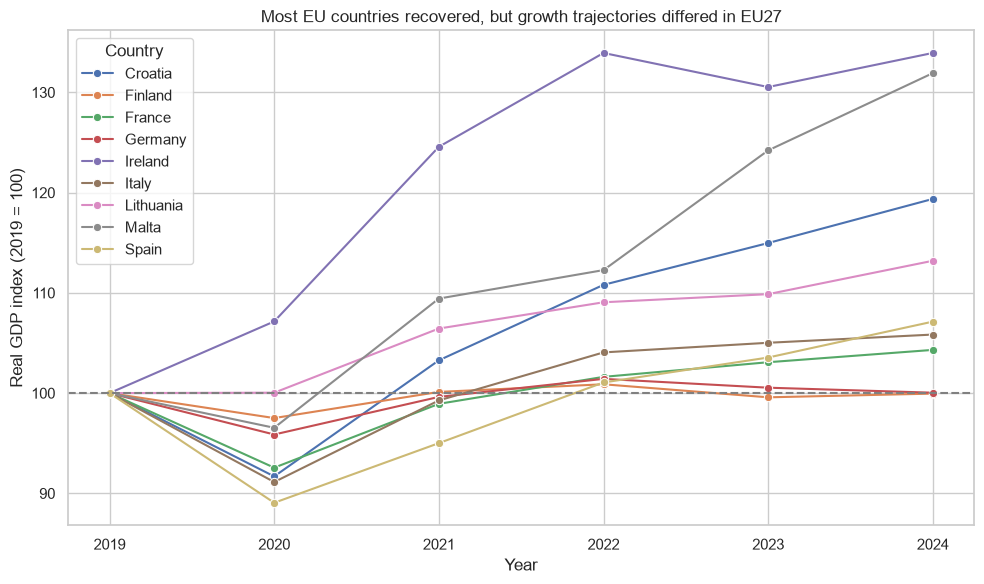

In [16]:
countries = ["Spain", "Croatia", "Germany", "Finland", "Malta", "France", "Italy", "Ireland", "Lithuania"]

gdp_plot = gdp_trajectories[
    gdp_trajectories["country_name"].isin(countries)
]

gdp_col = (
    "gdp_index"
    if "gdp_index" in gdp_plot.columns
    else "gdp_index_2019_equals_100"
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=gdp_plot,
    x="year",
    y=gdp_col,
    hue="country_name",
    marker="o"
)

plt.axhline(100, color="gray", linestyle="--")
plt.title("Most EU countries recovered, but growth trajectories differed in EU27")
plt.xlabel("Year")
plt.ylabel("Real GDP index (2019 = 100)")
plt.legend(title="Country")
plt.tight_layout()
plt.show()

**Graph for Research question 2: Inflation and GDP growth** (Scatter plot illustrating weak, statistically non-significant negative correlation.)

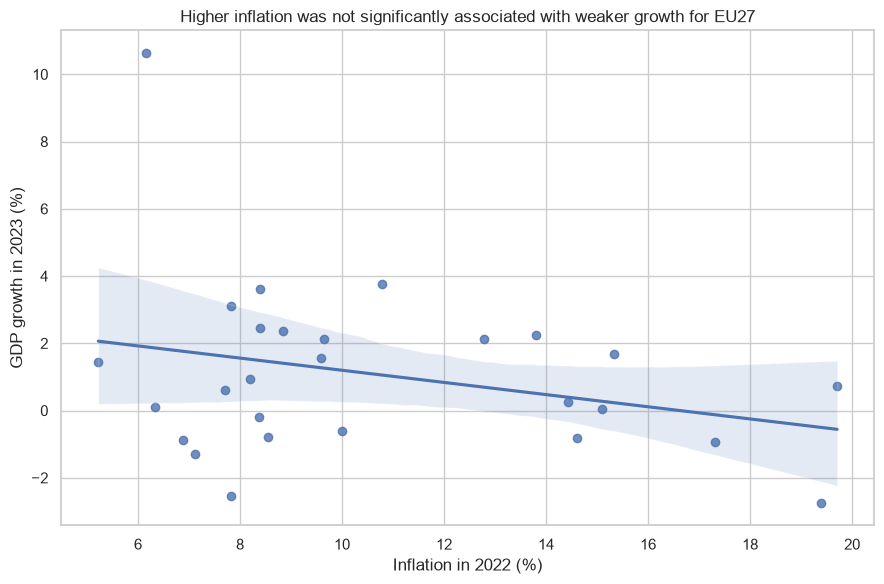

In [17]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=inflation_growth,
    x="inflation_2022",
    y="gdp_growth_2023"
)

plt.title("Higher inflation was not significantly associated with weaker growth for EU27")
plt.xlabel("Inflation in 2022 (%)")
plt.ylabel("GDP growth in 2023 (%)")
plt.tight_layout()
plt.show()

Calculating the correlation between both variables (inflation 2022 and GDP Growth 2023)

In [18]:
from scipy.stats import pearsonr, spearmanr
# Removing rows with missing values
rq2 = inflation_growth.dropna(
    subset=["inflation_2022", "gdp_growth_2023"]
)

# Calculate correlations
pearson_r2, pearson_p2 = pearsonr(
    rq2["inflation_2022"],
    rq2["gdp_growth_2023"]
)

spearman_r2, spearman_p2 = spearmanr(
    rq2["inflation_2022"],
    rq2["gdp_growth_2023"]
)

print("RQ2: Inflation and GDP growth")
print(f"Pearson r: {pearson_r2:.3f}, p-value: {pearson_p2:.4f}")
print(f"Spearman r: {spearman_r2:.3f}, p-value: {spearman_p2:.4f}")

RQ2: Inflation and GDP growth
Pearson r: -0.289, p-value: 0.1438
Spearman r: -0.112, p-value: 0.5790


Pearson correlation analysis identified a weak negative relationship between inflation in 2022 and GDP growth in 2023 (r = −0.289, p = 0.1438). Spearman correlation was considerably weaker (ρ = −0.112, p = 0.5790). Neither result was statistically significant at the 5% level. Therefore, the null hypothesis cannot be rejected.

Although the negative Pearson coefficient is consistent with the proposed hypothesis, the findings do not provide sufficient evidence of a systematic relationship between higher inflation and weaker subsequent GDP growth across the 27 EU countries.

**Graph for Research Question 3: Inflation and unemployment** (Scatter plot showing whether larger reductions in inflation coincided with higher unemployment)

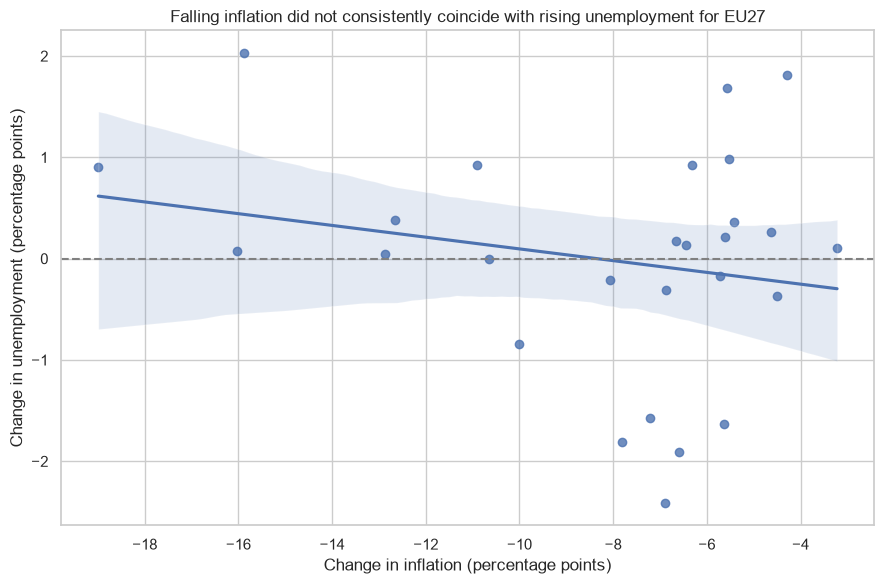

In [19]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=inflation_unemployment,
    x="inflation_change_pp",
    y="unemployment_change_pp"
)

plt.axhline(0, color="gray", linestyle="--")
plt.title("Falling inflation did not consistently coincide with rising unemployment for EU27")
plt.xlabel("Change in inflation (percentage points)")
plt.ylabel("Change in unemployment (percentage points)")
plt.tight_layout()
plt.show()

calculation corrlation between both variables: inflation and unemployment

In [20]:
rq3 = inflation_unemployment.dropna(
    subset=["inflation_change_pp", "unemployment_change_pp"]
)

# Calculate correlations
pearson_r3, pearson_p3 = pearsonr(
    rq3["inflation_change_pp"],
    rq3["unemployment_change_pp"]
)

spearman_r3, spearman_p3 = spearmanr(
    rq3["inflation_change_pp"],
    rq3["unemployment_change_pp"]
)

print("RQ3: Inflation and unemployment")
print(f"Pearson r: {pearson_r3:.3f}, p-value: {pearson_p3:.4f}")
print(f"Spearman r: {spearman_r3:.3f}, p-value: {spearman_p3:.4f}")

RQ3: Inflation and unemployment
Pearson r: -0.207, p-value: 0.3011
Spearman r: 0.091, p-value: 0.6507


Pearson correlation  identified a weak negative relationship between changes in inflation and unemployment between 2022 and 2024 (r = −0.207, p = 0.3011). However, Spearman correlation indicated a negligible positive relationship (ρ = 0.091, p = 0.6507). Neither result was statistically significant at the 5% level. Consequently, the null hypothesis cannot be rejected.

Although inflation declined in all 27 EU countries, unemployment increased in 16 countries, decreased in ten and remained unchanged in one. The results therefore provide insufficient evidence of a systematic relationship between larger reductions in inflation and greater increases in unemployment.

**Graph for RQ4 — Economic divergence: dispersion of gdp, inflation and unemployment**

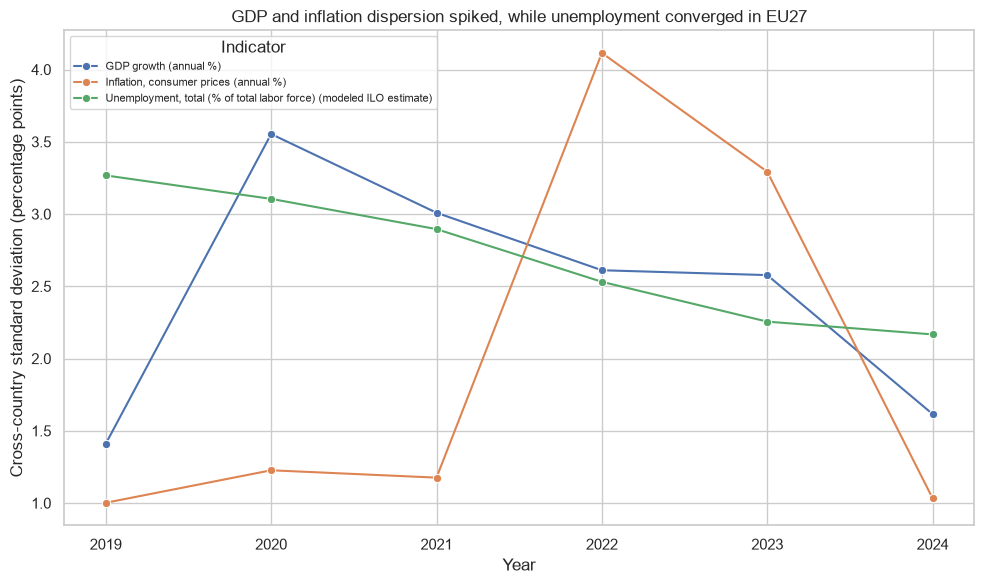

In [21]:
#suare root of variance was calculated in SQL, no need to repeat the agregation in pandas.
dispersion["std_dev"] = np.sqrt(dispersion["sample_variance"])

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=dispersion,
    x="year",
    y="std_dev",
    hue="indicator_name",
    marker="o"
)

plt.title("GDP and inflation dispersion spiked, while unemployment converged in EU27")
plt.xlabel("Year")
plt.ylabel("Cross-country standard deviation (percentage points)")
plt.legend(title="Indicator", fontsize=8)
plt.tight_layout()
plt.show()

# 5. Conclusions

This project investigated the post-pandemic and inflationary recovery of the 27 EU countries between 2019 and 2024. The findings show substantial differences in economic performance across countries, but limited evidence of statistically significant relationships between inflation and subsequent GDP growth or unemployment changes.

## Research Question 1: Which European countries recovered their pre-pandemic GDP levels by 2024?

**Hypothesis:** Most EU countries recovered their pre-pandemic GDP levels by 2024, although the timing and extent of recovery differed.

Out of the 27 EU countries analysed, 25 recorded a GDP contraction in 2020. Of these, 17 recovered their pre-pandemic GDP levels by 2021, while the remaining 8 first recovered in 2022.

By 2024, 24 of the 25 countries that had experienced a contraction were at or above their 2019 GDP levels. Finland was the only exception, with a GDP index of 99.95, although this was only marginally below its 2019 level.

The extent of recovery also differed considerably across countries. Malta reached a GDP index of 131.92 by 2024, while Germany reached only 100.04 relative to its 2019 baseline.

*Conclusion:* The hypothesis was supported. Most EU economies recovered their pre-pandemic output levels, but the timing and extent of recovery differed substantially across countries.

---

## Research Question 2: Was higher inflation in 2022 associated with weaker GDP growth in 2023?

**Hypothesis:** Countries experiencing higher inflation in 2022 subsequently recorded weaker GDP growth in 2023.

### Correlation results

| Test | Correlation | p-value |
|---|---:|---:|
| Pearson | -0.289 | 0.1438 |
| Spearman | -0.112 | 0.5790 |

The Pearson correlation showed a weak negative relationship, which was consistent with the direction of the hypothesis. However, neither the Pearson nor the Spearman correlation was statistically significant at the 5% level.

The SQL group comparison also showed that countries with above-average inflation recorded lower average GDP growth in 2023 (0.63%) than countries with at-or-below-average inflation (1.33%). However, this difference was strongly influenced by Malta's exceptionally high GDP growth.

*Conclusion:* The hypothesis was not statistically supported. The results suggest a possible weak negative association, but there is insufficient evidence of a consistent relationship between higher inflation in 2022 and weaker GDP growth in 2023 across the 27 EU countries.

---

## Research Question 3: Was the reduction in inflation between 2022 and 2024 associated with rising unemployment?

**Hypothesis:** Countries experiencing larger reductions in inflation also experienced greater increases in unemployment.

### Correlation results

| Test | Correlation | p-value |
|---|---:|---:|
| Pearson | -0.207 | 0.3011 |
| Spearman | 0.091 | 0.6507 |

Inflation declined in all 27 EU countries between 2022 and 2024. Despite this, unemployment increased in 16 countries, decreased in 10 countries, and remained unchanged in one country, Poland.

Neither correlation was statistically significant. The Spearman coefficient was also close to zero, suggesting that countries experiencing the largest reductions in inflation did not consistently experience the largest increases in unemployment.

*Conclusion:* The hypothesis was not statistically supported. Widespread disinflation was associated with mixed labour-market outcomes rather than a consistent increase in unemployment.

---

## Research Question 4: Did European economies become more similar or more divergent between 2019 and 2024?

**Hypothesis:** GDP growth and inflation dispersion increased during the respective economic shocks before declining by 2024, while unemployment followed a different trajectory.

### Cross-country variance

| Indicator | 2019 | Peak | 2024 |
|---|---:|---:|---:|
| GDP growth | 1.99 | 12.63 (2020) | 2.61 |
| Inflation | 1.00 | 16.93 (2022) | 1.07 |
| Unemployment | 10.67 | 10.67 (2019) | 4.70 |

GDP-growth dispersion increased considerably during the pandemic, with variance peaking in 2020. Inflation dispersion followed a similar shock-related pattern, reaching its highest level during the 2022 inflation shock. Both measures subsequently declined and approached their pre-shock levels by 2024.

Unemployment followed a different pattern. Cross-country unemployment variance declined steadily from 10.67 in 2019 to 4.70 in 2024, indicating that unemployment outcomes across EU countries became progressively less dispersed during the period analysed.

*Conclusion:* The descriptive hypothesis was supported. Economic shocks produced temporary increases in the dispersion of GDP growth and inflation, while unemployment dispersion declined throughout the period. However, this does not imply convergence in GDP levels, incomes, or living standards.

---

## Summary

The results show that most EU economies recovered their pre-pandemic GDP levels, but their subsequent economic trajectories differed substantially.

Higher inflation in 2022 was weakly associated with lower GDP growth in 2023, but this relationship was not statistically significant. Similarly, larger reductions in inflation between 2022 and 2024 were not significantly associated with increases in unemployment.

The strongest descriptive pattern was therefore not a stable relationship between inflation and either growth or unemployment, but rather the changing degree of economic dispersion across countries. GDP-growth differences widened sharply during the pandemic, inflation differences widened during the 2022 inflation shock, and both narrowed again by 2024. Unemployment dispersion, in contrast, declined throughout the period.

---
## 6. Limitations and next steps

What this data cannot tell you, and what you would do with another week. Knowing the limits of your own analysis is part of the grade.

**Limitations**
1. *Limited time period and sample size:* The analysis is based on a limited set of 27 countries over a relatively short period of time. Additionally, other factors apart from those considered in the analysis may have an impact on the economies of the studied countries, and the analysis does not take into account the presence of possible outliers. Moreover, since the calculation uses the equal weight of all countries, the results reflect the average characteristics of an EU country, not the entire economy of the EU. The results presented are therefore an exploratory analysis of possible relationships and differences between the economies of individual European countries.
2. *Correlation does not equal causation:* The correlation analyses cannot reveal any causal links between economic indicators, as exemplified by the statement that GDP growth in 2023 was impacted by inflation in 2022. GDP growth can be the result of monetary, fiscal, energy-price, trade-based and other policy decisions, of which inflation in 2022 is only one potential contributor. Similarly, the changes in unemployment cannot have a singular cause, and thus, its correlation with inflation does not imply causation.The aforementioned reasoning also applies to the absence of statistically significant results for RQ2 and RQ3, meaning that the lack of support for the research questions is not certain.
3. *Different national economic structures:* The analysis uses a pooled sample of all 27 EU members, despite evident theoretical differences in the size and specialisation of their economies. The individual country observations can also dominate the overall results, as with the GDP growth of Malta in 2023, which has an outsized impact on the RQ2 analysis. A similarly special case for Ireland’s GDP figures may be the activity of multinational enterprises.
4. *Limitations of the economic indicators:* The project uses three broad economic indicators: real GDP growth, consumer price inflation and unemployment. Despite representing key insights on macroeconomic developments, they fail to capture more nuanced aspects of convergence or divergence in living standards.Particularly, the convergence in GDP-growth rates does not equal that of GDP per capita or that of citizens’ personal income. Similarly, the declining unemployment does not automatically translate into improvements in working conditions or wages. Furthermore, the indicator of unemployment consists of the ILO-modelled figures, which can differ from the actual figures in national statistics.
5. *Descriptive analysis of economic dispersion:* RQ4 assesses the variance and standard deviation of the set of country-level indicators to identify dispersion, which only reveals whether the observed dispersion increased or decreased. Other factors, including extreme values in individual countries, can also drive changes in these measures.

--------

**Next Steps: What I Would Do With Another Week?**
1. Investigate outliers and test robustnessI would repeat the correlation analyses after screening for potentially influential observations, such as for Malta in RQ2. Comparing the results before and after would indicate whether the influential observations drove the overall results and if the conclusions were robust.
2. Expand the dataset and add more economic indicatorsI would attempt to add more economic indicators, including interest rates, government expenditure, energy prices and GDP per capita, among others. They would complement the analysis of factors associated with differences in economic recovery and offer more insights.
3. Extend the observation periodI would attempt to extend the time series backward to include several years preceding the COVID-19 pandemic to establish a baseline of the pre-pandemic economic levels. It would allow distinguishing between pandemic- and inflation-specific causes of change and provide more context for the observed levels of economic development.
4. Compare groups of EU countriesI would attempt to separate euro-area and non-euro-area countries in the analyses to assess if, for example, the patterns of recovery and inflation differed for these groups. It could highlight some of the factors which drove the differences between countries, but the interpretation would remain cautious, as the analysis would still pool the data on 27 countries.
5. Introduce more advanced statistical methodsWith more data and variables at hand, I would apply multivariate regression or a panel-data analysis to assess the links between inflation, growth and unemployment while controlling for other variables and thus approximating causality. The methods would be more advanced than descriptive statistics and correlation but would still only indicate potential, not proven, causal relationships.

---------

Overall, this project illustrates how SQL, Python and data visualisation can combine to study macroeconomic developments in the EU. Its main limitation is the inability to fully explain the forces driving the observed patterns, as demonstrated by the descriptive and correlational nature of the analyses. With more time, I would thus attempt to refine the results by screening for influential observations and adding more variables before attempting to draw more far-reaching conclusions.